# Análisis Exploratorio de Datos (EDA)

### Factores Ambientales

#### Carga de librerías

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [75]:
RAW_DIR = Path('..')/ 'data' / 'raw'
pach_parq = RAW_DIR / 'clima_zmvm_combined.parquet'

df = pd.read_parquet(pach_parq)

In [76]:
location_map = {
    "cdmx_aeropuerto": "Ciudad de México, Ciudad de México, México",
    "pachuca":         "Pachuca de Soto, Hidalgo, México",
    "toluca":          "Toluca de Lerdo, Estado de México, México",
}

df["location"] = df["station_id"].map(location_map)

df.head()

,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover,apparent_temperature,dewpoint_2m,station_id,lat,lon,location
0,2016-04-01 00:00:00,14.0,54,0.0,6.2,0.0,4,11.9,4.9,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
1,2016-04-01 01:00:00,13.1,59,0.0,6.5,0.0,0,11.1,5.4,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
2,2016-04-01 02:00:00,12.3,62,0.0,6.9,0.0,0,10.1,5.1,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
3,2016-04-01 03:00:00,11.5,64,0.0,7.3,0.0,3,9.2,4.9,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
4,2016-04-01 04:00:00,11.0,65,0.0,7.1,0.0,30,8.7,4.6,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"


In [77]:
df.shape

(230184, 13)

In [78]:
tabla_info = pd.DataFrame({
    
    "DataType" : df.dtypes,
    "No Nulos" : df.notnull().sum(),
    "Nulos" : df.isnull().sum(),
    "Porcentaje Nulos" : df.isnull().mean() * 100   

})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
datetime,datetime64[ns],230184,0,0.0
temperature_2m,float64,230184,0,0.0
relative_humidity_2m,int64,230184,0,0.0
precipitation,float64,230184,0,0.0
wind_speed_10m,float64,230184,0,0.0
shortwave_radiation,float64,230184,0,0.0
cloudcover,int64,230184,0,0.0
apparent_temperature,float64,230184,0,0.0
dewpoint_2m,float64,230184,0,0.0
station_id,object,230184,0,0.0


In [79]:
# --- Pachuca de Soto, Hidalgo ---
pachuca = df[df["location"] == "Pachuca de Soto, Hidalgo, México"].copy()

cols_interes = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "shortwave_radiation",
    "cloudcover",
]

pachuca.groupby(pachuca["datetime"].dt.year)[cols_interes].mean().round(1)

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover
datetime,,,,,,,
2016,14.8,14.3,79.3,0.1,7.2,233.7,68.3
2017,14.5,12.6,64.2,0.1,10.4,246.9,45.8
2018,14.5,12.7,67.5,0.1,10.3,242.1,51.5
2019,15.3,13.5,63.8,0.1,10.4,250.8,47.5
2020,15.2,13.3,63.0,0.0,10.7,255.2,45.4
2021,14.9,13.0,63.8,0.1,10.4,250.8,51.5
2022,14.9,12.9,63.6,0.1,10.6,260.7,51.4
2023,15.4,13.6,62.3,0.0,9.8,262.8,48.5
2024,15.9,14.2,60.5,0.1,9.0,259.8,52.6


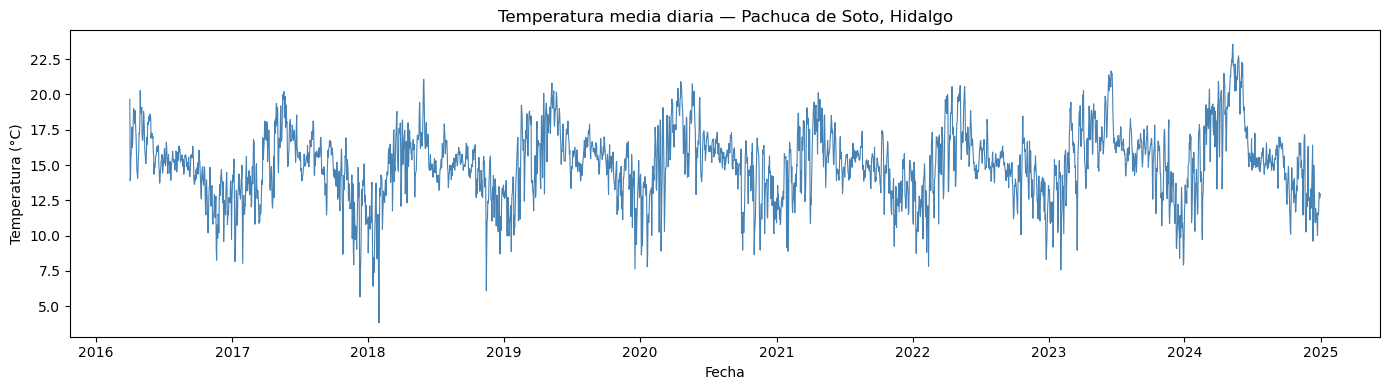

In [80]:
temp_diaria = pachuca.resample("D", on="datetime")["temperature_2m"].mean()

plt.figure(figsize=(14, 4))
plt.plot(temp_diaria, linewidth=0.8, color="steelblue")
plt.title("Temperatura media diaria — Pachuca de Soto, Hidalgo")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

In [81]:
# --- Ciudad de México ---
cdmx = df[df["location"] == "Ciudad de México, Ciudad de México, México"].copy()

cdmx.groupby(cdmx["datetime"].dt.year)[cols_interes].mean().round(1)

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover
datetime,,,,,,,
2016,16.2,15.7,72.5,0.1,6.3,234.3,63.9
2017,16.8,15.3,58.9,0.1,8.1,246.0,48.1
2018,16.4,15.3,64.1,0.2,7.6,238.2,55.6
2019,17.3,16.1,60.2,0.1,7.7,247.9,50.8
2020,17.5,16.1,58.3,0.1,8.1,252.5,48.2
2021,16.8,15.6,60.1,0.2,7.6,250.1,53.9
2022,16.8,15.5,60.4,0.1,7.8,261.2,53.1
2023,17.3,16.0,59.1,0.1,7.7,262.0,50.4
2024,17.7,16.5,56.5,0.1,7.1,259.9,54.2


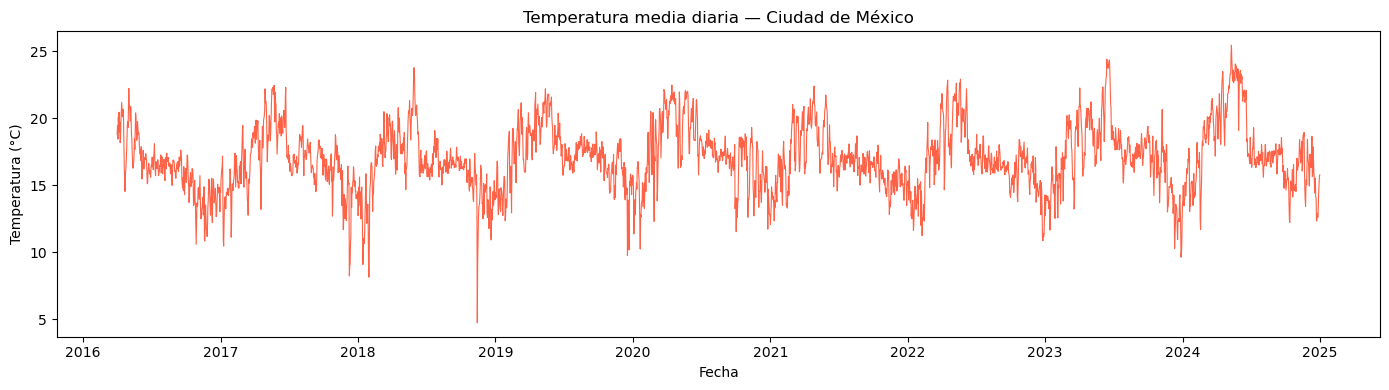

In [82]:
temp_diaria = cdmx.resample("D", on="datetime")["temperature_2m"].mean()

plt.figure(figsize=(14, 4))
plt.plot(temp_diaria, linewidth=0.8, color="tomato")
plt.title("Temperatura media diaria — Ciudad de México")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

In [83]:
# --- Toluca de Lerdo, Estado de México ---
toluca = df[df["location"] == "Toluca de Lerdo, Estado de México, México"].copy()

toluca.groupby(toluca["datetime"].dt.year)[cols_interes].mean().round(1)

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover
datetime,,,,,,,
2016,13.7,12.8,75.4,0.2,5.3,231.3,67.5
2017,13.6,11.5,58.9,0.1,8.1,250.2,45.5
2018,13.2,11.4,64.5,0.1,7.9,236.5,54.6
2019,14.0,12.1,61.3,0.1,7.9,247.1,49.8
2020,13.9,12.0,61.0,0.1,8.1,252.7,46.5
2021,13.4,11.5,62.4,0.1,8.2,248.3,52.2
2022,13.2,11.3,63.4,0.1,7.8,257.3,52.4
2023,14.1,12.2,60.0,0.1,7.7,260.2,48.0
2024,14.5,12.6,56.1,0.1,7.2,256.3,51.5


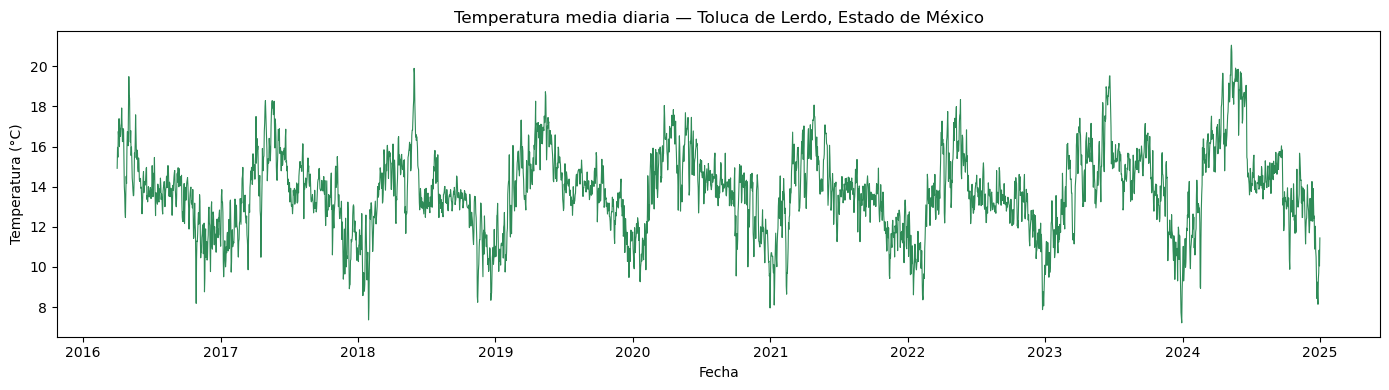

In [84]:
temp_diaria = toluca.resample("D", on="datetime")["temperature_2m"].mean()

plt.figure(figsize=(14, 4))
plt.plot(temp_diaria, linewidth=0.8, color="seagreen")
plt.title("Temperatura media diaria — Toluca de Lerdo, Estado de México")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()


#### Análisis de Estacionalidad

##### Temperatura media mensual por ciudad

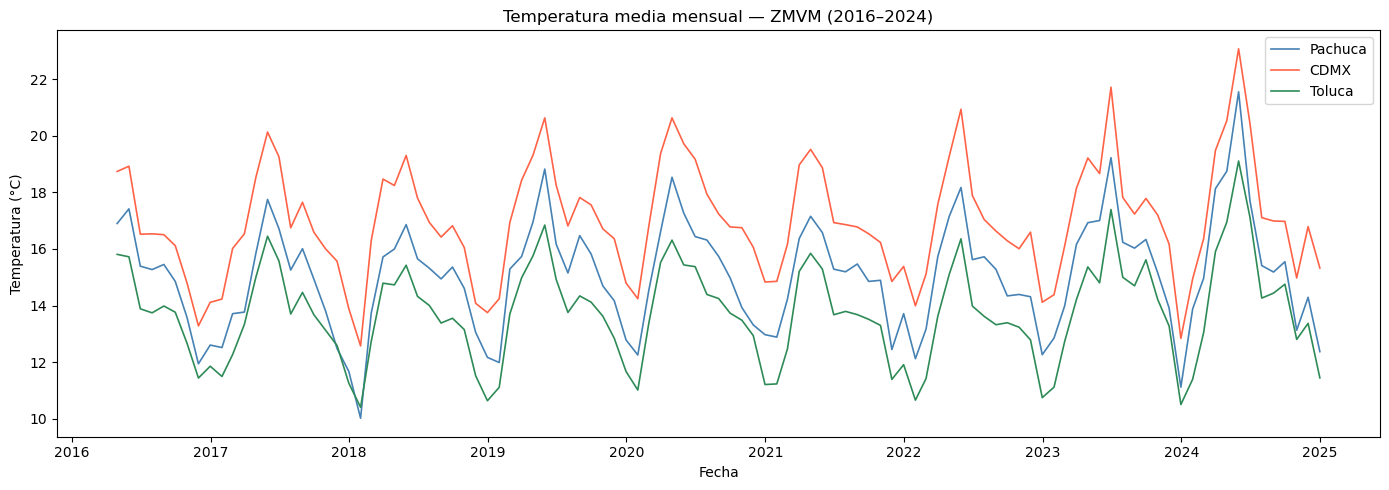

In [85]:
fig, ax = plt.subplots(figsize=(14, 5))

for ciudad, data, color in [
    ("Pachuca",  pachuca, "steelblue"),
    ("CDMX",     cdmx,    "tomato"),
    ("Toluca",   toluca,  "seagreen"),
]:
    temp_mensual = data.resample("M", on="datetime")["temperature_2m"].mean()
    ax.plot(temp_mensual, linewidth=1.2, label=ciudad, color=color)

ax.set_title("Temperatura media mensual — ZMVM (2016–2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.legend()
plt.tight_layout()
plt.show()

##### Boxplot mensual — patrón estacional por mes

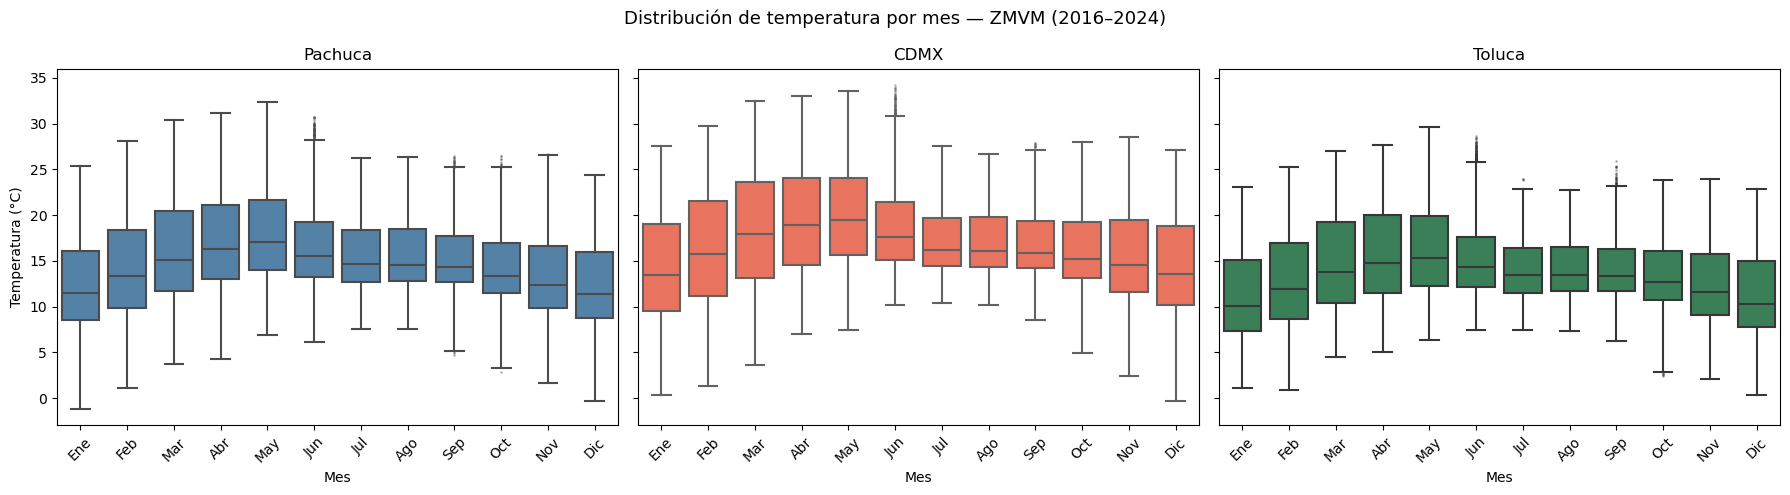

In [86]:
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (ciudad, data, color) in zip(axes, [
    ("Pachuca", pachuca, "steelblue"),
    ("CDMX",    cdmx,    "tomato"),
    ("Toluca",  toluca,  "seagreen"),
]):
    data_mes = data.copy()
    data_mes["mes"] = data_mes["datetime"].dt.month

    sns.boxplot(
        data=data_mes,
        x="mes",
        y="temperature_2m",
        ax=ax,
        color=color,
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    ax.set_title(ciudad)
    ax.set_xlabel("Mes")
    ax.set_ylabel("Temperatura (°C)" if ax == axes[0] else "")
    ax.set_xticklabels(meses, rotation=45)

fig.suptitle("Distribución de temperatura por mes — ZMVM (2016–2024)", fontsize=13)
plt.tight_layout()
plt.show()

### Datos económicos

In [87]:
ec_parq = RAW_DIR / 'economia_combined.parquet'

df_economia = pd.read_parquet(ec_parq)

df_economia.head().round(2)

,fecha,igae_total,imai_industrial,itaee_cdmx,itaee_hidalgo
0,2016-01-01,91.74,95.47,2957233.59,268833.62
1,2016-02-01,92.73,96.99,2957233.59,268833.62
2,2016-03-01,94.13,98.71,2957233.59,268833.62
3,2016-04-01,95.75,100.30,2957233.59,268833.62
4,2016-05-01,96.00,99.52,2957233.59,268833.62


In [88]:
df_economia.shape

(108, 5)

In [89]:
tabla_info = pd.DataFrame({
    
    "DataType" : df_economia.dtypes,
    "No Nulos" : df_economia.notnull().sum(),
    "Nulos" : df_economia.isnull().sum(),
    "Porcentaje Nulos" : df_economia.isnull().mean() * 100   

})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
fecha,datetime64[ns],108,0,0.0
igae_total,float64,108,0,0.0
imai_industrial,float64,108,0,0.0
itaee_cdmx,float64,108,0,0.0
itaee_hidalgo,float64,108,0,0.0


#### Estadísticas por año

In [90]:
cols_economia = ["igae_total", "imai_industrial", "itaee_cdmx", "itaee_hidalgo"]

tabla = (
    df_economia
    .groupby(df_economia["fecha"].dt.year)[cols_economia]
    .agg(["mean", "std"])
    .round(2)
)

tabla.columns = ["_".join(col) for col in tabla.columns]
tabla.index.name = "Año"
tabla

,igae_total_mean,igae_total_std,imai_industrial_mean,imai_industrial_std,itaee_cdmx_mean,itaee_cdmx_std,itaee_hidalgo_mean,itaee_hidalgo_std
Año,,,,,,,,
2016,96.17,2.63,99.21,1.79,2957233.59,0.0,268833.62,0.0
2017,98.02,2.93,99.83,2.71,3045539.86,0.0,270118.07,0.0
2018,100.00,2.42,100.00,2.63,3126459.57,0.0,276996.19,0.0
2019,99.56,1.88,98.26,2.62,3132839.08,0.0,272453.00,0.0
2020,91.57,7.91,89.57,9.72,2856971.79,0.0,244145.37,0.0
2021,96.73,3.01,95.29,2.70,2944607.21,0.0,251437.63,0.0
2022,100.10,3.44,99.82,2.91,2944607.21,0.0,251437.63,0.0
2023,103.19,3.01,102.78,3.34,2944607.21,0.0,251437.63,0.0
2024,104.53,2.28,102.17,2.73,2944607.21,0.0,251437.63,0.0


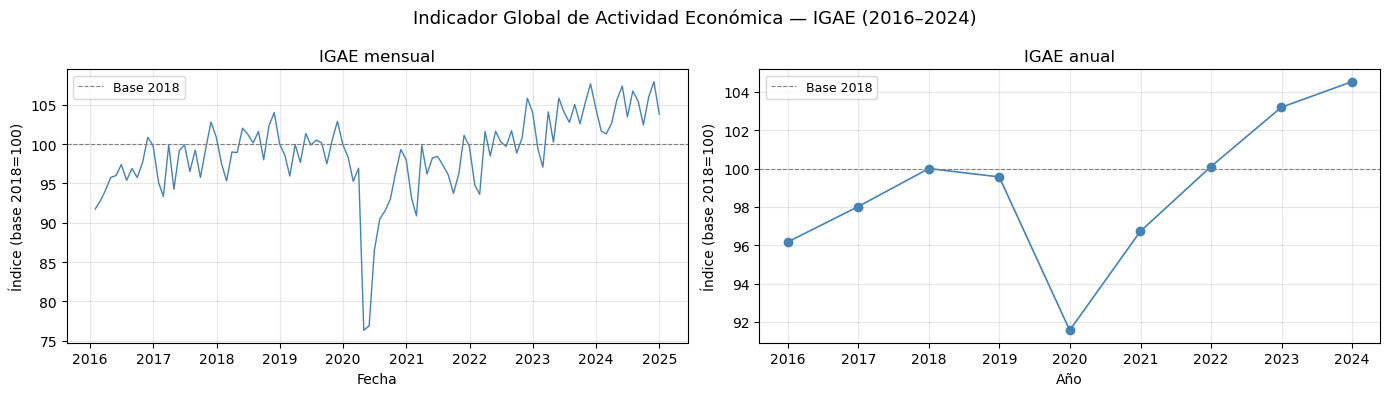

In [120]:
igae_mensual = df_economia.resample("M", on="fecha")["igae_total"].mean()
igae_anual = df_economia.resample("A", on="fecha", label="left")["igae_total"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(igae_mensual, linewidth=1.0, color="steelblue")
ax1.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax1.set_title("IGAE mensual")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Índice (base 2018=100)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(igae_anual, marker="o", linewidth=1.2, color="steelblue")
ax2.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax2.set_title("IGAE anual")
ax2.set_xlabel("Año")
ax2.set_ylabel("Índice (base 2018=100)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle("Indicador Global de Actividad Económica — IGAE (2016–2024)", fontsize=13)
plt.tight_layout()
plt.show()

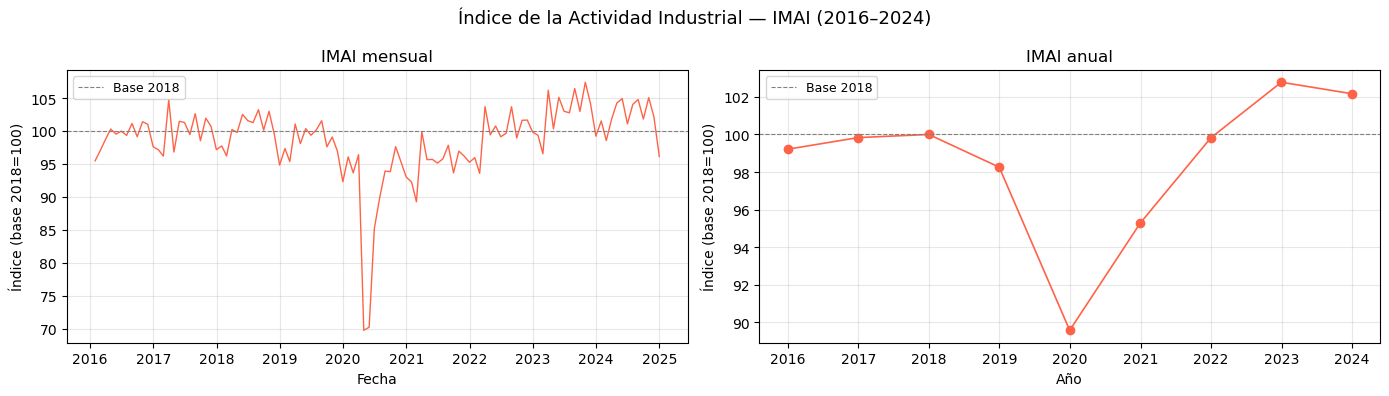

In [119]:
imai_mensual = df_economia.resample("M", on="fecha")["imai_industrial"].mean()
imai_anual   = df_economia.resample("A", on="fecha", label="left")["imai_industrial"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(imai_mensual, linewidth=1.0, color="tomato")
ax1.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax1.set_title("IMAI mensual")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Índice (base 2018=100)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(imai_anual, marker="o", linewidth=1.2, color="tomato")
ax2.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax2.set_title("IMAI anual")
ax2.set_xlabel("Año")
ax2.set_ylabel("Índice (base 2018=100)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle("Índice de la Actividad Industrial — IMAI (2016–2024)", fontsize=13)
plt.tight_layout()
plt.show()

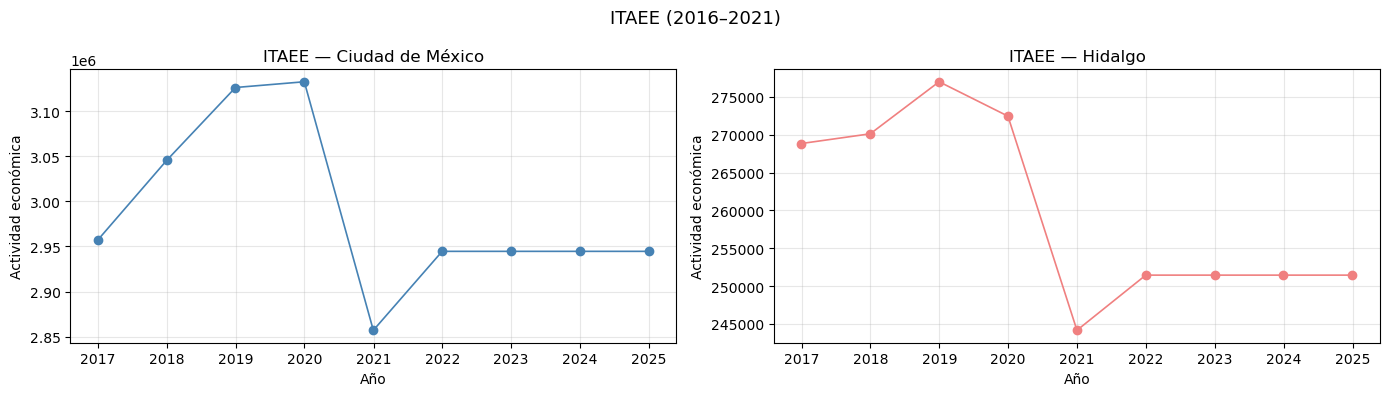

In [107]:
itaee_cdmx    = df_economia.resample("A", on="fecha")["itaee_cdmx"].mean()
itaee_hidalgo = df_economia.resample("A", on="fecha")["itaee_hidalgo"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(itaee_cdmx, marker="o", linewidth=1.2, color="steelblue")
ax1.set_title("ITAEE — Ciudad de México")
ax1.set_xlabel("Año")
ax1.set_ylabel("Actividad económica")
ax1.grid(alpha=0.3)

ax2.plot(itaee_hidalgo, marker="o", linewidth=1.2, color="lightcoral")
ax2.set_title("ITAEE — Hidalgo")
ax2.set_xlabel("Año")
ax2.set_ylabel("Actividad económica")
ax2.grid(alpha=0.3)

plt.suptitle("ITAEE (2016–2021)", fontsize=13)
plt.tight_layout()
plt.show()

El ITAEE muestra un crecimiento sostenido hasta 2019, seguido de una caída abrupta en 2021 como consecuencia de la pandemia COVID-19. Destaca que ambas economías no lograron recuperar los niveles pre-pandemia, estabilizándose en una meseta inferior. Esta contracción estructural es relevante para el modelo predictivo, ya que la actividad económica es un predictor de la demanda eléctrica — una economía que no se recupera sugiere una demanda que tampoco debería hacerlo completamente. Importante: los valores de 2022 en adelante son proyecciones por forward-fill del último dato publicado por INEGI (2021), ya que el ITAEE tiene un rezago de publicación de aproximadamente 3 años.

### Demanda Real

In [91]:
dem_parq = RAW_DIR / 'demanda_real_combined.parquet'

df_demanda = pd.read_parquet(dem_parq)

df_demanda.head().round(2)

,sistema,area,hora,generacion_mwh,exportacion_total_mwh,demanda_balance_mwh,source_file,importacion_mwh,intercambio_mwh,fecha
0,BCA,BCA,1,1272.17,115.0,1157.17,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
1,BCS,BCS,1,191.33,0.0,191.33,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
2,SIN,CEN,1,4828.71,0.0,4828.71,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
3,SIN,NES,1,9737.85,0.0,9737.85,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
4,SIN,NOR,1,2261.77,0.0,2261.77,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01


In [92]:
tabla_info = pd.DataFrame({
    
    "DataType" : df_demanda.dtypes,
    "No Nulos" : df_demanda.notnull().sum(),
    "Nulos" : df_demanda.isnull().sum().round(2),
    "Porcentaje Nulos" : df_demanda.isnull().mean().round(2) * 100   

})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
sistema,object,3151218,0,0.0
area,object,3151218,0,0.0
hora,int64,3151218,0,0.0
generacion_mwh,float64,3151218,0,0.0
exportacion_total_mwh,float64,2788984,362234,11.0
demanda_balance_mwh,float64,3151218,0,0.0
source_file,object,3151218,0,0.0
importacion_mwh,float64,1870552,1280666,41.0
intercambio_mwh,object,1870552,1280666,41.0
fecha,datetime64[ns],3151218,0,0.0


#### Filtrado — CEN (ZMVM) y columnas relevantes

In [93]:
# Filtrar solo área CEN (Gerencia Central = ZMVM)
df_cen = df_demanda[df_demanda["area"] == "CEN"][["fecha", "hora", "demanda_balance_mwh"]].copy()

# Resetear índice
df_cen = df_cen.sort_values(["fecha", "hora"]).reset_index(drop=True)

print(f"Registros totales:  {len(df_demanda):,}")
print(f"Registros CEN:      {len(df_cen):,}")
print(f"Rango:              {df_cen['fecha'].min().date()} → {df_cen['fecha'].max().date()}")
print(f"Columnas:           {list(df_cen.columns)}")
df_cen.head()

Registros totales:  3,151,218
Registros CEN:      350,135
Rango:              2016-04-01 → 2024-12-31
Columnas:           ['fecha', 'hora', 'demanda_balance_mwh']


,fecha,hora,demanda_balance_mwh
0,2016-04-01,1,4828.708
1,2016-04-01,1,4829.277
2,2016-04-01,1,4667.381
3,2016-04-01,2,4702.795
4,2016-04-01,2,4703.316


##### Serie temporal

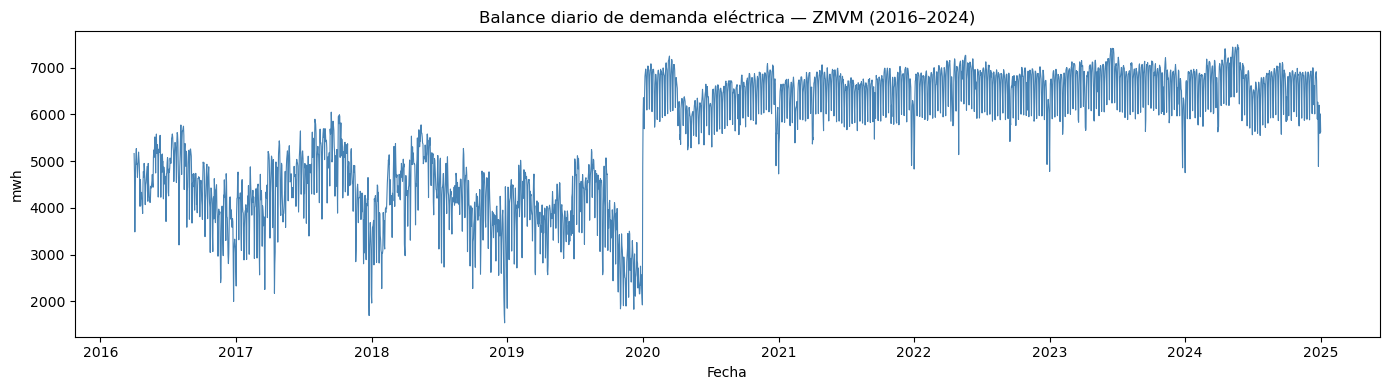

In [94]:
daily_demand = df_cen.resample("D",on="fecha")["demanda_balance_mwh"].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily_demand, linewidth=0.8, color="steelblue")
plt.title("Balance diario de demanda eléctrica — ZMVM (2016–2024)")
plt.xlabel("Fecha")
plt.ylabel("mwh")
plt.tight_layout()
plt.show()

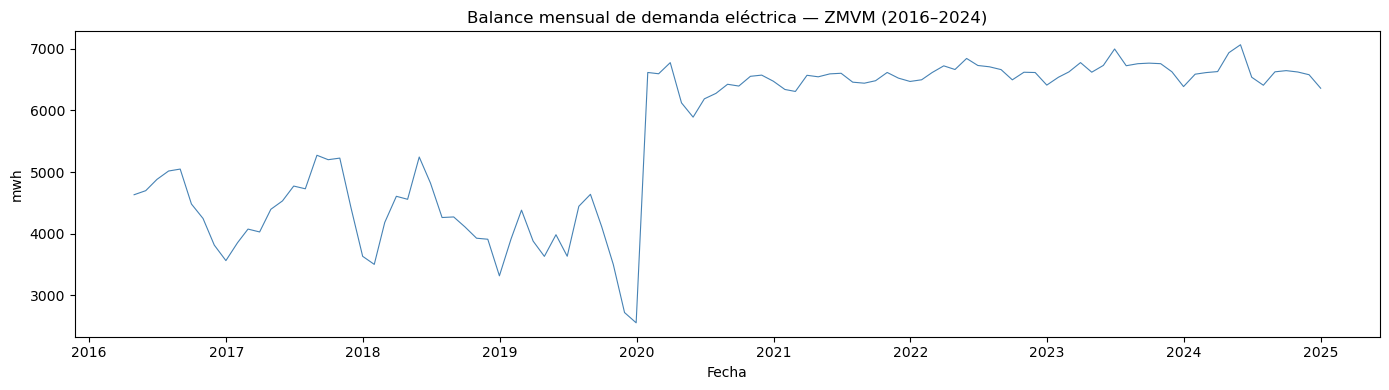

In [95]:
monthly_demand = df_cen.resample("M",on="fecha")["demanda_balance_mwh"].mean()

plt.figure(figsize=(14, 4))
plt.plot(monthly_demand, linewidth=0.8, color="steelblue")
plt.title("Balance mensual de demanda eléctrica — ZMVM (2016–2024)")
plt.xlabel("Fecha")
plt.ylabel("mwh")
plt.tight_layout()
plt.show()

##### Perfiles Mensuales y Diarios

El dataset trae una hora 25 con 31 registros, que no es coherente. Por lo que se omiten estos datos en el perfil por hora. 

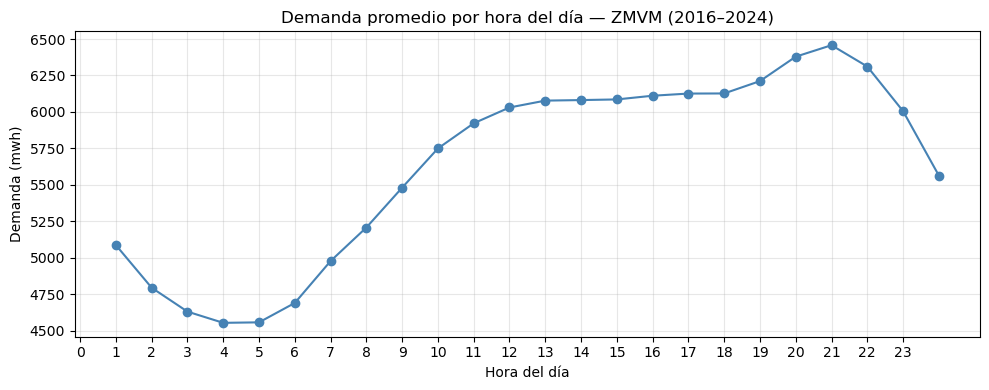

In [96]:
df_cen = df_cen[df_cen["hora"] <= 24]
hour = df_cen.groupby("hora")["demanda_balance_mwh"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hour.index, hour.values, marker="o", color="steelblue")
plt.title("Demanda promedio por hora del día — ZMVM (2016–2024)")
plt.xlabel("Hora del día")
plt.ylabel("Demanda (mwh)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

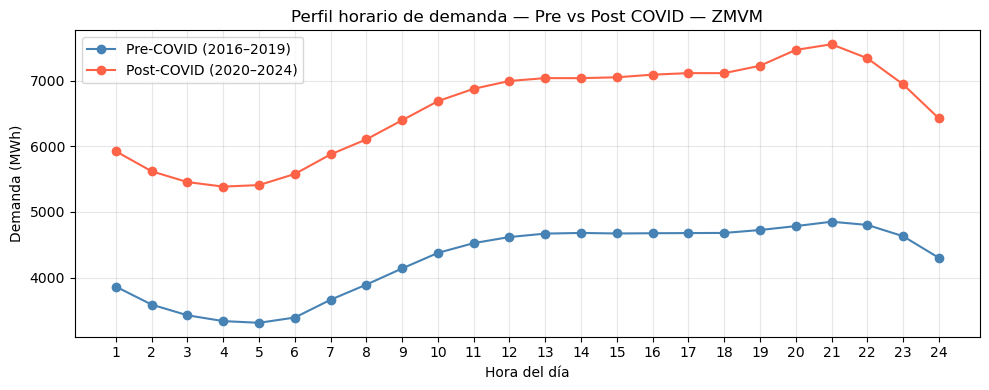

In [97]:
df_cen = df_demanda[df_demanda["area"] == "CEN"][["fecha", "hora", "demanda_balance_mwh"]].copy()
df_cen = df_cen.sort_values(["fecha", "hora"]).reset_index(drop=True)
df_cen = df_cen[df_cen["hora"] <= 24]

pre_covid  = df_cen[df_cen["fecha"].dt.year < 2020]
post_covid = df_cen[df_cen["fecha"].dt.year >= 2020]

hour_pre  = pre_covid.groupby("hora")["demanda_balance_mwh"].mean()
hour_post = post_covid.groupby("hora")["demanda_balance_mwh"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hour_pre.index,  hour_pre.values,  marker="o", color="steelblue", label="Pre-COVID (2016–2019)")
plt.plot(hour_post.index, hour_post.values, marker="o", color="tomato",    label="Post-COVID (2020–2024)")
plt.title("Perfil horario de demanda — Pre vs Post COVID — ZMVM")
plt.xlabel("Hora del día")
plt.ylabel("Demanda (MWh)")
plt.xticks(range(1, 25))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

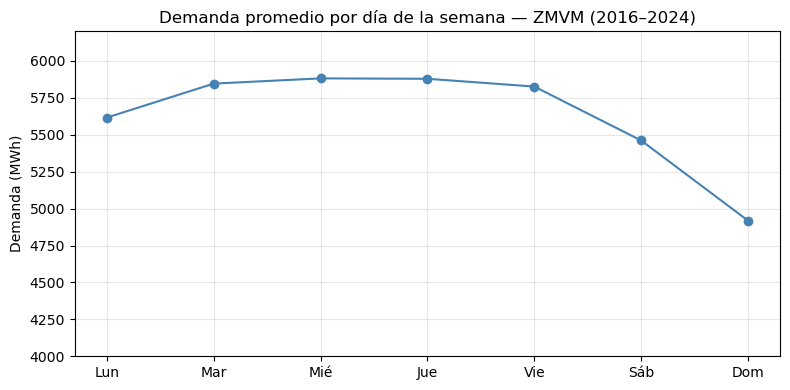

In [98]:
df_cen["dia_sem"] = df_cen["fecha"].dt.dayofweek

weekly = df_cen.groupby("dia_sem")["demanda_balance_mwh"].mean()

dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

plt.figure(figsize=(8, 4))
plt.plot(weekly.index, weekly.values, marker="o", color="steelblue")
plt.xticks(range(7), dias)
plt.ylim(4000, 6200)
plt.title("Demanda promedio por día de la semana — ZMVM (2016–2024)")
plt.ylabel("Demanda (MWh)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### PML

In [123]:
RAW_DIR = Path('..')/ 'data' / 'raw'
pach_parq = RAW_DIR / 'pml_zmvm_MDA_2016-01-01_2024-12-31.parquet'

df_pml = pd.read_parquet(pach_parq)

df_pml.head()

,nodo,nombre,mercado,hora,fecha,pml,pml_ene,pml_per,pml_cng
0,01ACO-230,Acolman,MDA,1,2016-01-29,774.66,773.97,0.65,0.04
1,01ACO-230,Acolman,MDA,10,2016-01-29,826.11,829.8,-3.72,0.04
2,01ACO-230,Acolman,MDA,11,2016-01-29,859.94,867.6,-7.42,-0.24
3,01ACO-230,Acolman,MDA,12,2016-01-29,838.92,842.49,-3.35,-0.22
4,01ACO-230,Acolman,MDA,13,2016-01-29,885.67,891.54,-5.78,-0.1


In [126]:
tabla_info = pd.DataFrame({
    "DataType" : df_pml.dtypes,
    "No Nulos" : df_pml.notnull().sum(),
    "Nulos" : df_pml.isnull().sum(),
    "Porcentaje Nulos" : df_pml.isnull().mean() * 100   
})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
nodo,object,4977557,0,0.0
nombre,object,4977557,0,0.0
mercado,object,4977557,0,0.0
hora,object,4977557,0,0.0
fecha,datetime64[ns],4977557,0,0.0
pml,object,4977557,0,0.0
pml_ene,object,4977557,0,0.0
pml_per,object,4977557,0,0.0
pml_cng,object,4977557,0,0.0


#### Mapa de nodos ZMVM

In [ ]:
import folium

# Coordenadas aproximadas de los 68 nodos (230kV) — ZMVM
# Zona: N=VDM Norte, S=VDM Sur, C=Centro Oriente (corredor CDMX-Pachuca)
NODOS_COORDS = {
    # VDM NORTE
    "01ACO-230": ("Acolman",                   19.637, -98.912, "N"),
    "01ATI-230": ("Atizapan",                  19.558, -99.248, "N"),
    "01ATK-230": ("Aztecas",                   19.470, -99.173, "N"),
    "01AZC-230": ("Azcapotzalco",              19.487, -99.185, "N"),
    "01BBV-230": ("BBVA Centro Tecnologico",   19.395, -99.260, "N"),
    "01CEI-230": ("Ceilan",                    19.457, -99.155, "N"),
    "01CFI-230": ("Cofraida",                  19.520, -99.200, "N"),
    "01CPM-230": ("Carton y Papel de Mexico",  19.458, -99.065, "N"),
    "01CRG-230": ("Cerro Gordo",               19.655, -98.958, "N"),
    "01CTG-230": ("Cartagena",                 19.540, -99.018, "N"),
    "01ECA-230": ("Ecatepec",                  19.601, -99.050, "N"),
    "01EVD-230": ("El Vidrio",                 19.450, -99.048, "N"),
    "01JLC-230": ("Jabon La Corona",           19.455, -99.060, "N"),
    "01LAR-230": ("Las Americas",              19.482, -99.230, "N"),
    "01LDG-230": ("Lago de Guadalupe",         19.608, -99.223, "N"),
    "01LVE-230": ("Lomas Verdes",              19.513, -99.257, "N"),
    "01MAD-230": ("Madero",                    19.430, -99.133, "N"),
    "01MLP-230": ("Chimalpa",                  19.418, -99.290, "N"),
    "01OCE-230": ("Oceania",                   19.448, -99.108, "N"),
    "01REM-230": ("Remedios",                  19.533, -99.158, "N"),
    "01ROL-230": ("Caracol",                   19.490, -99.000, "N"),
    "01SOX-230": ("Sosa Texcoco",              19.430, -98.920, "N"),
    "01TCM-230": ("Tecamac",                   19.714, -98.970, "N"),
    "01TEH-230": ("Tecamachalco",              19.453, -99.035, "N"),
    "01TKM-230": ("Tecamac Movil",             19.712, -98.967, "N"),
    "01TTH-230": ("Teotihuacan",               19.692, -98.844, "N"),
    "01VAE-230": ("Valle de Mexico",           19.530, -99.072, "N"),
    "01VAJ-230": ("Vallejo",                   19.473, -99.148, "N"),
    "01VIC-230": ("Victoria",                  19.600, -99.150, "N"),
    "01XAL-230": ("Xalostoc",                  19.561, -99.033, "N"),
    # VDM SUR
    "01AGU-230": ("Aguilas",                   19.373, -99.220, "S"),
    "01ATE-230": ("Atenco",                    19.558, -98.917, "S"),
    "01AYO-230": ("Ayotla",                    19.363, -98.893, "S"),
    "01CJM-230": ("Cuajimalpa",                19.357, -99.297, "S"),
    "01COA-230": ("Coapa",                     19.305, -99.138, "S"),
    "01CRS-230": ("Contreras",                 19.298, -99.235, "S"),
    "01CRU-230": ("Santa Cruz",                19.390, -99.250, "S"),
    "01CUL-230": ("Culhuacan",                 19.328, -99.115, "S"),
    "01DVA-230": ("Deportiva",                 19.395, -99.050, "S"),
    "01ECR-230": ("El Cerrito",                19.320, -99.050, "S"),
    "01EST-230": ("Estadio",                   19.303, -99.153, "S"),
    "01IXL-230": ("Ixtapaluca",                19.312, -98.878, "S"),
    "01IZT-230": ("Iztapalapa",                19.360, -99.050, "S"),
    "01MOR-230": ("Morelos",                   19.200, -99.000, "S"),
    "01ODB-230": ("Odon de Buen",              19.390, -99.155, "S"),
    "01OLI-230": ("Olivar",                    19.352, -99.188, "S"),
    "01RSL-230": ("El Rosal",                  19.265, -99.200, "S"),
    "01SNG-230": ("San Angel",                 19.348, -99.200, "S"),
    "01TAX-230": ("Taxquena",                  19.333, -99.130, "S"),
    "01TDK-230": ("Toluca 2000",               19.293, -99.670, "S"),
    "01TIA-230": ("Tianguistenco",             19.170, -99.470, "S"),
    "01TOP-230": ("Topilejo",                  19.218, -99.145, "S"),
    "01TTC-230": ("Totoltepec",                19.300, -99.550, "S"),
    "01TTU-230": ("Tren Interurbano Mex-Tol",  19.380, -99.300, "S"),
    "01XOC-230": ("Xochimilco",                19.257, -99.103, "S"),
    "01ZAM-230": ("Zaragoza Movil",            19.400, -99.015, "S"),
    # CENTRO ORIENTE — corredor CDMX-Pachuca
    "01ACS-230": ("Aceros Corsa",              19.950, -98.950, "C"),
    "01AFM-230": ("AIFA Maniobras",            19.983, -99.016, "C"),
    "01CCZ-230": ("Cementera Cruz Azul",       20.037, -99.114, "C"),
    "01IRO-230": ("Irolo",                     20.010, -98.640, "C"),
    "01JRB-230": ("Jorobas",                   19.893, -99.120, "C"),
    "01LFG-230": ("Lafarge",                   20.050, -99.350, "C"),
    "01OTM-230": ("Otumba Maniobras",          19.700, -98.754, "C"),
    "01PEM-230": ("Pemex Maniobras",           20.050, -99.320, "C"),
    "01PYG-230": ("Procter and Gamble",        19.560, -99.048, "C"),
    "01RAT-230": ("Atotonilco PTAR",           20.093, -99.213, "C"),
    "01TCC-230": ("Tula Ciclo Combinado",      20.055, -99.330, "C"),
    "01TIZ-230": ("Tizayuca",                  19.978, -98.978, "C"),
    "01TUL-230": ("Tula",                      20.047, -99.337, "C"),
}

COLORES = {"N": "blue", "S": "red", "C": "green"}
ZONAS   = {"N": "VDM Norte", "S": "VDM Sur", "C": "Centro Oriente"}

mapa = folium.Map(location=[19.6, -99.1], zoom_start=9)

for clave, (nombre, lat, lon, zona) in NODOS_COORDS.items():
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=COLORES[zona],
        fill=True,
        fill_opacity=0.8,
        tooltip=f"{clave} — {nombre} ({ZONAS[zona]})",
        popup=f"<b>{nombre}</b><br>{clave}<br>Zona: {ZONAS[zona]}",
    ).add_to(mapa)

# Leyenda manual
leyenda = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:10px; border-radius:8px; border:1px solid gray; font-size:13px">
  <b>Zonas CENACE</b><br>
  <span style="color:blue">●</span> VDM Norte<br>
  <span style="color:red">●</span> VDM Sur<br>
  <span style="color:green">●</span> Centro Oriente (Corredor CDMX-Pachuca)
</div>
"""
mapa.get_root().html.add_child(folium.Element(leyenda))
mapa

In [127]:
pip install geopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 1.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
